In [2]:
import pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt, seaborn as sns

url = "https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv"
df = pd.read_csv(url)

df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0


In [5]:
df["Shot"] = (df["eventName"] == "Shot").astype(int) 

In [6]:
x_max = 120
y_max = 75
df["x2"] = (df["x2"]/ 100) * x_max
df["x1"] = (df["x1"]/ 100) * x_max
df["y2"] = (df["y2"]/ 100) * y_max
df["y1"] = (df["y1"]/ 100) * y_max
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,Shot
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,60.0,37.5,42.0,39.75,0


In [11]:
box_h = 44
box_w = 18

box_ymin = (y_max / 2) - (box_h / 2)
box_ymax = (y_max / 2) + (box_h / 2)
box_xmax = x_max
box_xmin = x_max - 18

df["g_event"] = (
    (df["y1"] > box_ymin)&
    (df["y1"] < box_ymax)&
    (df["x1"] > box_xmin)&
    (df["x1"] < box_xmax)
    ).astype(int)

df["g_event"].sum()

np.int64(3989)

In [19]:
g_df = df.groupby(["matchId", "teamId"]).agg(
    shots = ("Shot", "sum"),
    g_events = ("g_event", "sum"),
).reset_index()
g_df

,matchId,teamId,shots,g_events
0,"Argentina - Croatia, 0 - 3",Argentina,10,34
1,"Argentina - Croatia, 0 - 3",Croatia,13,25
2,"Argentina - Iceland, 1 - 1",Argentina,22,56
3,"Argentina - Iceland, 1 - 1",Iceland,8,25
4,"Australia - Peru, 0 - 2",Australia,11,48
...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,16
124,"Uruguay - Russia, 3 - 0",Russia,3,15
125,"Uruguay - Russia, 3 - 0",Uruguay,12,24
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,16


AttributeError: Axes.set() got an unexpected keyword argument 'ylable'

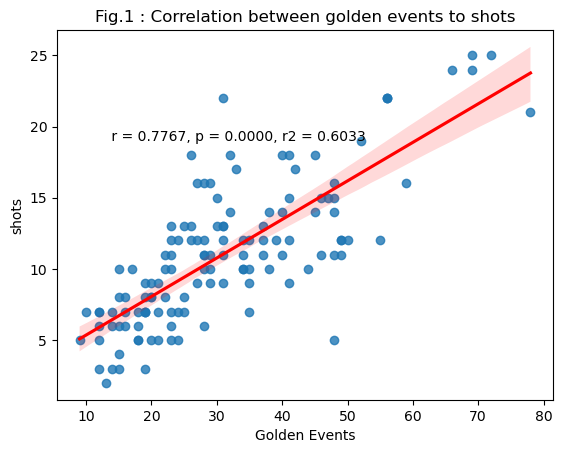

In [20]:
r, p =stats.pearsonr(g_df["g_events"], g_df["shots"])
r2 = r **2

text = (f" r = {r:.4f}, p = {p:.4f}, r2 = {r2:.4f}")

reg = sns.regplot(data=g_df, x = "g_events", y = "shots", line_kws = {"color": "r", "label": "Line of best fit"})
reg.text(x=0.1, y = 0.7, s = text, transform = reg.transAxes)
reg.set(title = "Fig.1 : Correlation between golden events to shots",
        xlabel = "Golden Events",
        ylable= "shots")

plt.legend()
plt.show()